In [ ]:
# %% [markdown]
# # ResNet Training Strategy 3: Curriculum Learning (Prediction Difficulty) - V2 [PyTorch]
#
# CIFAR-10: 60,000 32x32 colour images in 10 classes
# - 50,000 training images | 10,000 test images
# - Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
#
# **Strategy**: Curriculum Learning based on prediction difficulty.
#
# 1. Train a scorer ResNet briefly on the full dataset to estimate sample difficulty.
# 2. Rank training samples by per-sample loss from easy to hard.
# 3. Train the final ResNet in stages, starting with the easiest samples and gradually introducing harder ones:
#    - Stage 1: Easiest 20% (10 epochs)
#    - Stage 2: Easiest 40% (10 epochs)
#    - Stage 3: Easiest 60% (10 epochs)
#    - Stage 4: Easiest 80% (10 epochs)
#    - Stage 5: All 100% (10 epochs)
#
# Total: 50 epochs
#
# **V2 Hyperparameter Changes (model architecture unchanged):**
# - Learning rate: 0.0001 → 0.001
# - Scorer epochs: 3 → 5
# - Epochs per stage: 5 → 10 (total: 50)
# - Batch size: 64 → 128
# - Added ReduceLROnPlateau learning rate scheduler
#
# **PyTorch port**: Uses PyTorch + torchvision ResNet50 with CUDA GPU acceleration (RTX 3060).


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

D:\ANACONDA\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
print(f"Using device: {device}")

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
CUDA version: 12.1
Using device: cuda


In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [7]:
# ## Part 1 - Loading CIFAR-10 Data
# Download CIFAR-10 (raw, no transforms yet — we need raw data for scoring)
raw_trainset = torchvision.datasets.CIFAR10(root='./dataset', train=True, download=True)
raw_testset = torchvision.datasets.CIFAR10(root='./dataset', train=False, download=True)

# Extract raw numpy arrays
x_train_raw = np.array(raw_trainset.data)       # (50000, 32, 32, 3) uint8
y_train_raw = np.array(raw_trainset.targets)     # (50000,)
x_test_raw = np.array(raw_testset.data)
y_test_raw = np.array(raw_testset.targets)

print(f"Train: {x_train_raw.shape}, Test: {x_test_raw.shape}")

100%|██████████| 170M/170M [00:52<00:00, 3.22MB/s] 


Extracting ./dataset\cifar-10-python.tar.gz to ./dataset
Files already downloaded and verified
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


In [9]:
# Transforms: Training with augmentation, Test without
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=12, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


In [11]:
# Custom dataset class that works with numpy arrays + transforms
class CIFAR10Numpy(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images   # uint8 numpy (N, 32, 32, 3)
        self.labels = labels   # int numpy (N,)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]          # (32, 32, 3) uint8
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        return img, label



In [13]:

# Test dataloader (no augmentation)
test_dataset = CIFAR10Numpy(x_test_raw, y_test_raw, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

In [15]:
# ## Part 2 - Building the ResNet
#
# We use torchvision's ResNet50 with `weights=None` (train from scratch) and adapt the
# first conv layer and final FC layer for CIFAR-10's 32×32 images and 10 classes.

# %%
def build_resnet():
    """Build a ResNet50 adapted for CIFAR-10 (32x32 input, 10 classes)."""
    model = models.resnet50(weights=None)

    # Replace first conv: original uses 7x7 stride 2 (for ImageNet 224x224).
    # For 32x32 CIFAR, use 3x3 stride 1, no maxpool, to preserve spatial dims.
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()  # Remove maxpool for small images

    # Replace final FC: 2048 → 256 → 10 (matching the TF version's head)
    model.fc = nn.Sequential(
        nn.Flatten(),
        nn.BatchNorm1d(2048),
        nn.Linear(2048, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 10)
    )
    return model

# %%
# Quick sanity check
_test_model = build_resnet().to(device)
_test_input = torch.randn(2, 3, 32, 32).to(device)
_test_output = _test_model(_test_input)
print(f"Model output shape: {_test_output.shape}")  # Should be [2, 10]
del _test_model, _test_input, _test_output
torch.cuda.empty_cache()


Model output shape: torch.Size([2, 10])


In [17]:
# ## Part 3 - Scoring Samples by Difficulty
#
# A lightly trained scorer model estimates per-sample loss so the training data
# can be ordered from easy to hard.
#
# **V2 Change:** Scorer now trains for 5 epochs (was 3) with learning rate 0.001
# (was 0.0001) for better difficulty estimation.

# %%
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


In [19]:

# %%
print("Building scorer model to assess sample difficulty...")
scorer = build_resnet().to(device)
scorer_optimizer = optim.Adam(scorer.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

scorer_train_dataset = CIFAR10Numpy(x_train_raw, y_train_raw, transform=train_transform)
scorer_train_loader = DataLoader(scorer_train_dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)

for epoch in range(5):
    train_loss, train_acc = train_one_epoch(scorer, scorer_train_loader, criterion, scorer_optimizer, device)
    print(f"  Scorer Epoch {epoch+1}/5 - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")

print("\nScorer training complete.")

# %%
print("Computing per-sample difficulty scores...")

# Use non-augmented data for consistent scoring
score_dataset = CIFAR10Numpy(x_train_raw, y_train_raw, transform=test_transform)
score_loader = DataLoader(score_dataset, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

scorer.eval()
all_losses = []
with torch.no_grad():
    for images, labels in score_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = scorer(images)
        # Per-sample cross-entropy loss
        loss_per_sample = nn.functional.cross_entropy(outputs, labels, reduction='none')
        all_losses.append(loss_per_sample.cpu().numpy())

per_sample_loss = np.concatenate(all_losses)

print(f"\nDifficulty score statistics:")
print(f"  Min loss (easiest):  {per_sample_loss.min():.4f}")
print(f"  Max loss (hardest):  {per_sample_loss.max():.4f}")
print(f"  Mean loss:           {per_sample_loss.mean():.4f}")
print(f"  Median loss:         {np.median(per_sample_loss):.4f}")

# Free scorer memory
del scorer, scorer_optimizer, scorer_train_loader, score_loader
torch.cuda.empty_cache()

# %%
difficulty_order = np.argsort(per_sample_loss)

x_train_sorted = x_train_raw[difficulty_order]
y_train_sorted = y_train_raw[difficulty_order]
loss_sorted = per_sample_loss[difficulty_order]

print("Training data sorted by difficulty (easy → hard).")
print(f"  Easiest 5 losses: {loss_sorted[:5]}")
print(f"  Hardest 5 losses: {loss_sorted[-5:]}")


Building scorer model to assess sample difficulty...
  Scorer Epoch 1/5 - Loss: 1.6809, Acc: 0.3926
  Scorer Epoch 2/5 - Loss: 1.2992, Acc: 0.5318
  Scorer Epoch 3/5 - Loss: 1.1841, Acc: 0.5762
  Scorer Epoch 4/5 - Loss: 1.1436, Acc: 0.5948
  Scorer Epoch 5/5 - Loss: 0.9995, Acc: 0.6481

Scorer training complete.
Computing per-sample difficulty scores...

Difficulty score statistics:
  Min loss (easiest):  0.0000
  Max loss (hardest):  13.9700
  Mean loss:           0.8681
  Median loss:         0.2914
Training data sorted by difficulty (easy → hard).
  Easiest 5 losses: [2.3841855e-07 2.3841855e-07 2.3841855e-07 4.7683704e-07 4.7683704e-07]
  Hardest 5 losses: [12.337082 12.896047 13.011381 13.103637 13.969986]


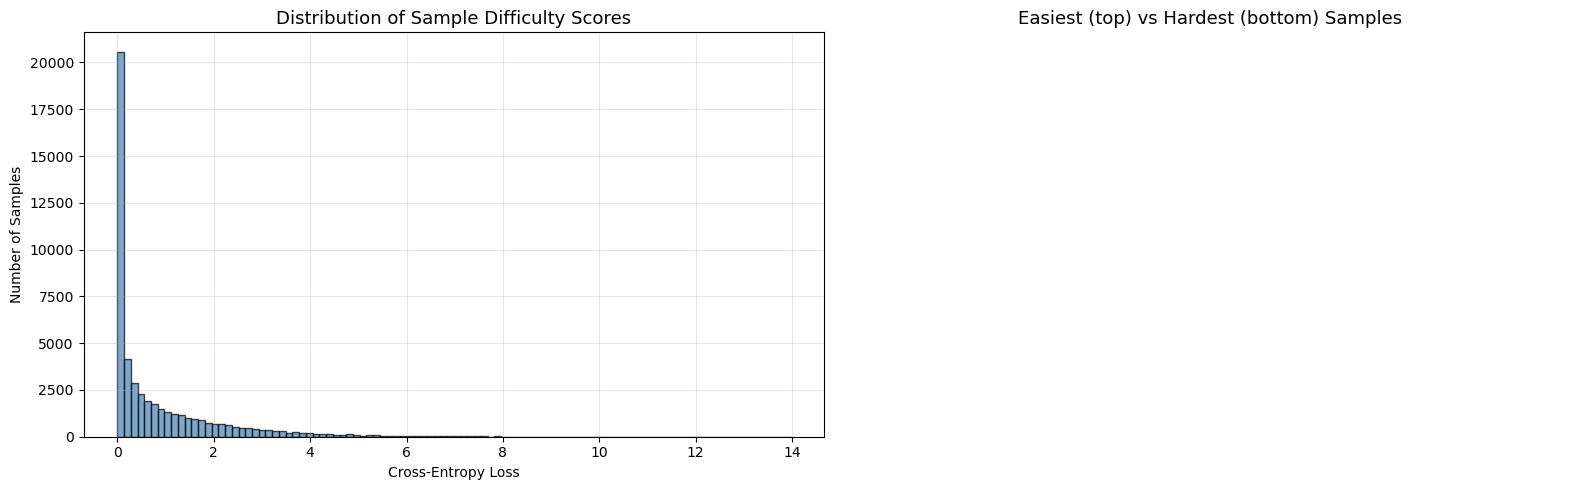

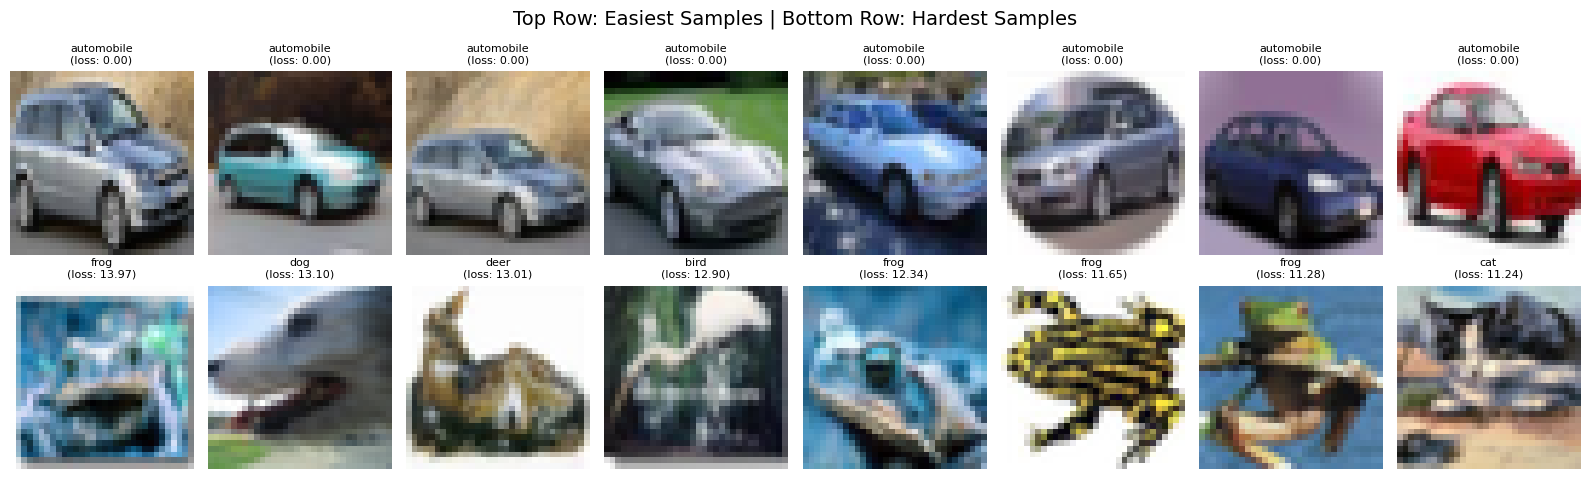

In [21]:

# %% [markdown]
# ### Visualize the difficulty distribution

# %%
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(per_sample_loss, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Sample Difficulty Scores', fontsize=13)
axes[0].set_xlabel('Cross-Entropy Loss')
axes[0].set_ylabel('Number of Samples')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Easiest (top) vs Hardest (bottom) Samples', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Top Row: Easiest Samples | Bottom Row: Hardest Samples', fontsize=14)

for i in range(8):
    axes[0, i].imshow(x_train_sorted[i])
    true_label = int(y_train_sorted[i])
    axes[0, i].set_title(f'{class_names[true_label]}\n(loss: {loss_sorted[i]:.2f})', fontsize=8)
    axes[0, i].axis('off')

    idx = -(i + 1)
    axes[1, i].imshow(x_train_sorted[idx])
    true_label = int(y_train_sorted[idx])
    axes[1, i].set_title(f'{class_names[true_label]}\n(loss: {loss_sorted[idx]:.2f})', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [23]:

# %% [markdown]
# ## Part 4 - Curriculum Training
#
# Now we train a fresh model using the curriculum (easy → hard) ordering.
#
# **V2 Changes:**
# - Learning rate: 0.001 (was 0.0001)
# - Epochs per stage: 10 (was 5), total 50 epochs
# - Batch size: 128 (was 64)
# - Added ReduceLROnPlateau callback (patience=3, factor=0.5)

# %%
curriculum_fractions = [0.20, 0.40, 0.60, 0.80, 1.00]
epochs_per_stage = 5

print("Curriculum Learning Schedule (Easy → Hard):")
print("=" * 60)
for i, frac in enumerate(curriculum_fractions):
    n_samples = int(len(x_train_sorted) * frac)
    start_loss = loss_sorted[0]
    end_loss = loss_sorted[n_samples - 1]
    print(f"Stage {i + 1}: Easiest {frac*100:.0f}% → {n_samples:,} samples "
          f"(loss range: {start_loss:.3f} - {end_loss:.3f}) ({epochs_per_stage} epochs)")
print(f"\nTotal epochs: {len(curriculum_fractions) * epochs_per_stage}")

# %%
resnet_model = build_resnet().to(device)
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6, verbose=True)

# Print model parameter count
total_params = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# %%
full_history = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': []
}

stage_boundaries = []

for stage_idx, fraction in enumerate(curriculum_fractions):
    n_samples = int(len(x_train_sorted) * fraction)
    x_subset = x_train_sorted[:n_samples]
    y_subset = y_train_sorted[:n_samples]

    train_dataset = CIFAR10Numpy(x_subset, y_subset, transform=train_transform)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)

    start_loss = loss_sorted[0]
    end_loss = loss_sorted[n_samples - 1]

    print(f"\n{'='*70}")
    print(f"STAGE {stage_idx + 1}/{len(curriculum_fractions)}: Training with easiest {fraction*100:.0f}% ({n_samples:,} samples)")
    print(f"Loss range: {start_loss:.3f} - {end_loss:.3f}")
    print(f"{'='*70}")

    stage_boundaries.append(len(full_history['train_acc']))

    for epoch in range(epochs_per_stage):
        train_loss, train_acc = train_one_epoch(resnet_model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(resnet_model, test_loader, criterion, device)
        scheduler.step(val_loss)

        full_history['train_acc'].append(train_acc)
        full_history['val_acc'].append(val_acc)
        full_history['train_loss'].append(train_loss)
        full_history['val_loss'].append(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1}/{epochs_per_stage} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, LR: {current_lr:.6f}")

    print(f"\nStage {stage_idx + 1} Complete:")
    print(f"  Train Accuracy: {full_history['train_acc'][-1]:.4f}")
    print(f"  Val Accuracy:   {full_history['val_acc'][-1]:.4f}")

print(f"\n{'='*70}")
print("Curriculum learning complete!")
print(f"{'='*70}")



Curriculum Learning Schedule (Easy → Hard):
Stage 1: Easiest 20% → 10,000 samples (loss range: 0.000 - 0.010) (5 epochs)
Stage 2: Easiest 40% → 20,000 samples (loss range: 0.000 - 0.123) (5 epochs)
Stage 3: Easiest 60% → 30,000 samples (loss range: 0.000 - 0.568) (5 epochs)
Stage 4: Easiest 80% → 40,000 samples (loss range: 0.000 - 1.581) (5 epochs)
Stage 5: Easiest 100% → 50,000 samples (loss range: 0.000 - 13.970) (5 epochs)

Total epochs: 25


D:\ANACONDA\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Total parameters: 24,031,562
Trainable parameters: 24,031,562

STAGE 1/5: Training with easiest 20% (10,000 samples)
Loss range: 0.000 - 0.010
  Epoch 1/5 - Train Loss: 1.1665, Train Acc: 0.5923, Val Loss: 4.7555, Val Acc: 0.3133, LR: 0.001000
  Epoch 2/5 - Train Loss: 0.6850, Train Acc: 0.7686, Val Loss: 4.4139, Val Acc: 0.3689, LR: 0.001000
  Epoch 3/5 - Train Loss: 0.4367, Train Acc: 0.8528, Val Loss: 4.5230, Val Acc: 0.3971, LR: 0.001000
  Epoch 4/5 - Train Loss: 0.3616, Train Acc: 0.8840, Val Loss: 5.4953, Val Acc: 0.3938, LR: 0.001000
  Epoch 5/5 - Train Loss: 0.2758, Train Acc: 0.9089, Val Loss: 4.4322, Val Acc: 0.4382, LR: 0.001000

Stage 1 Complete:
  Train Accuracy: 0.9089
  Val Accuracy:   0.4382

STAGE 2/5: Training with easiest 40% (20,000 samples)
Loss range: 0.000 - 0.123
  Epoch 1/5 - Train Loss: 0.5603, Train Acc: 0.8184, Val Loss: 2.5304, Val Acc: 0.4958, LR: 0.001000
  Epoch 2/5 - Train Loss: 0.4180, Train Acc: 0.8615, Val Loss: 2.3449, Val Acc: 0.5379, LR: 0.001000


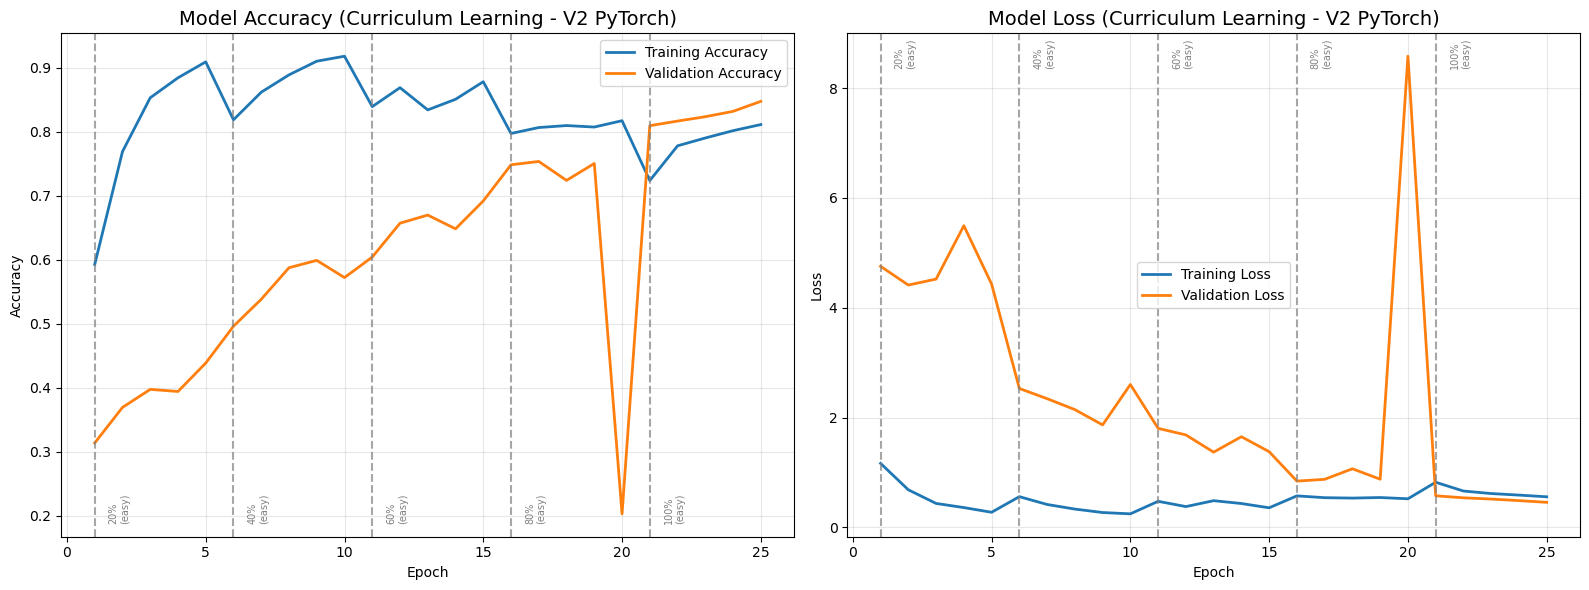


Test Loss     : 0.4572
Test Accuracy : 0.8472
Model saved to cifar10_resnet_curriculum_v2_pytorch.pth
Predicted class : deer (100.0% confidence)
Actual class    : deer


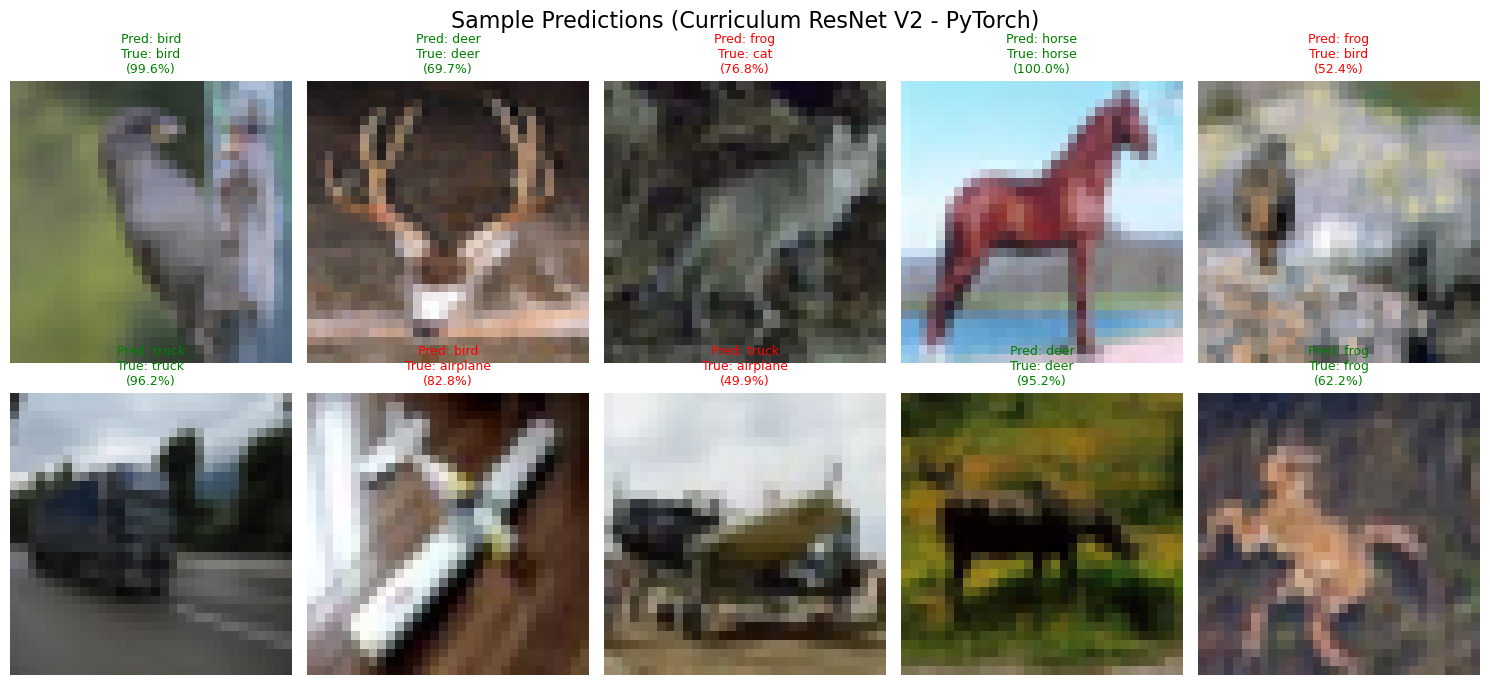

In [25]:
# %% [markdown]
# ## Part 5 - Evaluating the Results

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(full_history['train_acc']) + 1)

ax1.plot(epochs_range, full_history['train_acc'], label='Training Accuracy', linewidth=2)
ax1.plot(epochs_range, full_history['val_acc'], label='Validation Accuracy', linewidth=2)
for i, boundary in enumerate(stage_boundaries):
    frac = curriculum_fractions[i]
    ax1.axvline(x=boundary + 1, color='gray', linestyle='--', alpha=0.7)
    ax1.text(boundary + 1.5, ax1.get_ylim()[0] + 0.02, f'{frac*100:.0f}%\n(easy)',
             fontsize=7, color='gray', rotation=90, va='bottom')

ax1.set_title('Model Accuracy (Curriculum Learning - V2 PyTorch)', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, full_history['train_loss'], label='Training Loss', linewidth=2)
ax2.plot(epochs_range, full_history['val_loss'], label='Validation Loss', linewidth=2)
for i, boundary in enumerate(stage_boundaries):
    frac = curriculum_fractions[i]
    ax2.axvline(x=boundary + 1, color='gray', linestyle='--', alpha=0.7)
    ax2.text(boundary + 1.5, ax2.get_ylim()[1] - 0.1, f'{frac*100:.0f}%\n(easy)',
             fontsize=7, color='gray', rotation=90, va='top')

ax2.set_title('Model Loss (Curriculum Learning - V2 PyTorch)', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
test_loss, test_accuracy = evaluate(resnet_model, test_loader, criterion, device)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

# %%
# Save model
torch.save(resnet_model.state_dict(), 'cifar10_resnet_curriculum_v2_pytorch.pth')
print("Model saved to cifar10_resnet_curriculum_v2_pytorch.pth")

# %% [markdown]
# ## Part 6 - Making a single prediction

# %%
idx = np.random.randint(0, len(x_test_raw))
test_image = x_test_raw[idx]

test_image_tensor = test_transform(test_image).unsqueeze(0).to(device)

resnet_model.eval()
with torch.no_grad():
    result = resnet_model(test_image_tensor)
    probabilities = torch.softmax(result, dim=1)
    predicted_class = probabilities.argmax(dim=1).item()
    confidence = probabilities[0][predicted_class].item() * 100
    actual_class = int(y_test_raw[idx])

print(f"Predicted class : {class_names[predicted_class]} ({confidence:.1f}% confidence)")
print(f"Actual class    : {class_names[actual_class]}")

# %%
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Sample Predictions (Curriculum ResNet V2 - PyTorch)', fontsize=16)

resnet_model.eval()
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(x_test_raw))
    test_img = x_test_raw[idx]
    test_img_tensor = test_transform(test_img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = resnet_model(test_img_tensor)
        probs = torch.softmax(pred, dim=1)
        pred_cls = probs.argmax(dim=1).item()
        conf = probs[0][pred_cls].item() * 100
        actual_cls = int(y_test_raw[idx])

    ax.imshow(test_img)
    color = 'green' if pred_cls == actual_cls else 'red'
    ax.set_title(f'Pred: {class_names[pred_cls]}\nTrue: {class_names[actual_cls]}\n({conf:.1f}%)',
                 fontsize=9, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()
